   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Accuracy: 0.9013605442176871

Classification Report:

              precision    recall  f1-score   support

           0       0.90      1.00      0.95       255
           1       0.92      0.28      0.43        39

    accuracy                           0.90       294
   macro avg       0.91      0.64      0.69       294
weighted avg       0.90      0.90      0.88       294


Confusion Matrix:

[[254   1]
 [ 28  11]]


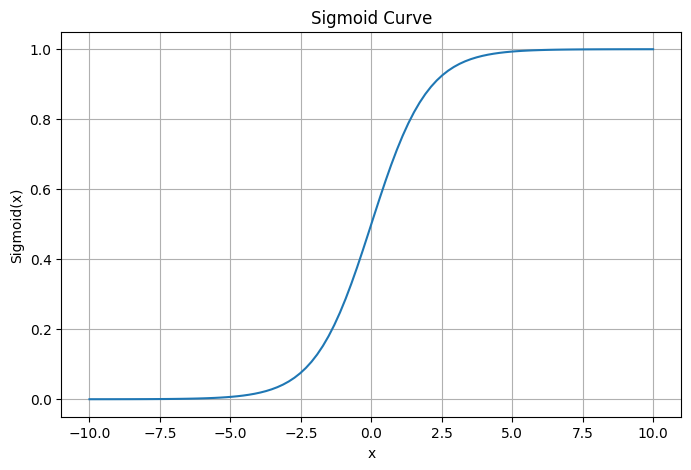

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
df = pd.read_csv("/content/drive/MyDrive/MLT /HR-Employee-Attrition.csv")
print(df.head())
print(df.isnull().sum())


for col in df.columns:
    if df[col].isnull().sum() > 0:
        # For categorical columns
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        # For numerical columns
        else:
            df[col].fillna(df[col].mean(), inplace=True)

print("\nTotal Missing Values After Handling:")
print(df.isnull().sum().sum())


# Encoding categorical columns
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])


# Features and Target
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2,random_state=42)


# Logistic Regression
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# SIGMOID CURVE

x = np.linspace(-10, 10, 100)
sigmoid = 1 / (1 + np.exp(-x))

# Plot sigmoid curve
plt.figure(figsize=(8,5))
plt.plot(x, sigmoid)
plt.title("Sigmoid Curve")
plt.xlabel("x")
plt.ylabel("Sigmoid(x)")
plt.grid(True)
plt.show()